## Анализ данных А/В тестирования

Описание проекта
В компании проводится A/B-тестирование с целью увеличить показатели.
Необходимо:
* проанализировать корректность проведения и результаты A/B-теста.

Исходные данные: файл с результатами A/B-теста.

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

### Загрузка данных и подготовка к анализу

In [56]:
df = pd.read_csv('/content/marketing_AB.csv')

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


In [58]:
df.head(10)

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14
5,5,1137664,ad,False,734,Saturday,10
6,6,1116205,ad,False,264,Wednesday,13
7,7,1496843,ad,False,17,Sunday,18
8,8,1448851,ad,False,21,Tuesday,19
9,9,1446284,ad,False,142,Monday,14


Видим, что явных пустых значений в данных нет. Колонка Unnamed: 0 повторяет индексацию строк и не несет информационной нагрузки, поэтому её можно удалить.

In [59]:
df.drop(columns='Unnamed: 0', inplace=True)

Поменяем тип столбца converted на int

In [60]:
df['converted'] = df['converted'].astype('int')

Преобразуем названия колонок в более удобные для использования

In [61]:
df.columns = ['user_id', 'test_group', 'converted', 'total_ads', 'most_ads_day', 'most_ads_hour']
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   user_id        588101 non-null  int64 
 1   test_group     588101 non-null  object
 2   converted      588101 non-null  int64 
 3   total_ads      588101 non-null  int64 
 4   most_ads_day   588101 non-null  object
 5   most_ads_hour  588101 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 26.9+ MB


Проверим наличие пользователей, попавших в обе тестовые группы

In [62]:
intersect_users = pd.merge(df[df['test_group'] == 'ad']['user_id'], df[df['test_group'] == 'psa']['user_id'], how='inner')
intersect_users

,user_id


Таких пользователей нет. Распределение было проведено правильно.

##### Проверим распределения категориальных признаков

In [91]:
print('Количество уникальных пользователей:', df['user_id'].nunique())
print('Уникальные значения в колонке test_group:', df['test_group'].unique())
print('Уникальные значения в колонке most_ads_day:', df['most_ads_day'].unique())

Количество уникальных пользователей: 588101
Уникальные значения в колонке test_group: ['ad' 'psa']
 ['Monday' 'Tuesday' 'Friday' 'Saturday' 'Wednesday' 'Sunday' 'Thursday']


In [71]:
test_group_parts = df.groupby('test_group')['test_group'].agg(['count']).reset_index()
test_group_parts.columns = ['test_group', 'count']
test_group_parts['test_group_of_total'] = test_group_parts['count'] / 588101
test_group_parts

,test_group,count,test_group_of_total
0,ad,564577,0.96
1,psa,23524,0.04


In [77]:
converted_parts = df.groupby('converted')['converted'].agg(lambda x: x.count() / 588101)
converted_parts

,converted
converted,
0,0.974761
1,0.025239


In [78]:
converted_parts_by_test_group = df.groupby('test_group')['converted'].agg(lambda x: x.sum()/x.count())
converted_parts_by_test_group

,converted
test_group,
ad,0.025547
psa,0.017854


In [93]:
most_ads_day_part =  df.groupby('most_ads_day')['most_ads_day'].agg('count')
most_ads_day_part

,most_ads_day
most_ads_day,
Friday,92608
Monday,87073
Saturday,81660
Sunday,85391
Thursday,82982
Tuesday,77479
Wednesday,80908


По рапределению тестовых групп виден сильный дисбаланс (96% и 4%). В распределение конверсии видно сильное преобладание нулевого значения (что нормально для этого показателя). В распределении конверсии по тестовым группам очень большого различия не наблюдается. В распределении дней с максимальным количеством показанной рекламы дисбаланса нет.

##### Рассмотрим распределения числовых признаков

In [95]:
df['total_ads'].describe()

,total_ads
count,588101.000000
mean,24.820876
std,43.715181
min,1.000000
25%,4.000000
50%,13.000000
75%,27.000000
max,2065.000000


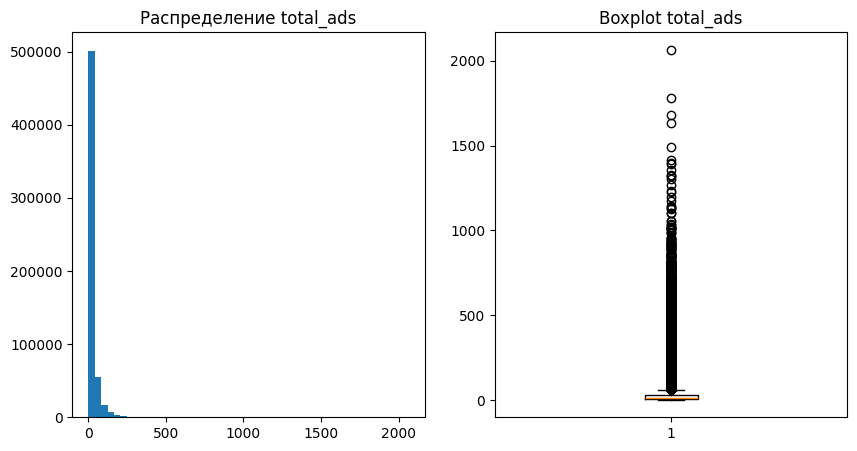

In [102]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(df['total_ads'], bins=50)
plt.title('Распределение total_ads')
plt.subplot(1, 2, 2)
plt.boxplot(df['total_ads'])
plt.title('Boxplot total_ads')
plt.show()

In [109]:
df[df['total_ads'] > 70].head()

,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour
0,1069124,ad,0,130,Monday,20
1,1119715,ad,0,93,Tuesday,22
3,1435133,ad,0,355,Tuesday,10
4,1015700,ad,0,276,Friday,14
5,1137664,ad,0,734,Saturday,10


Распределение сильно скошенно влево, однако выбросов слишком много, чтобы их удалить без влияния на результат анализа, к тому же записи с большими значениями выглядят нормально. Таким образом, оставляем распределение в исходном виде

### Анализ A/B теста

##### Сравнение конверсий по тестовым группам

In [120]:
conv_ad = df[df['test_group'] == 'ad']['converted'].mean()
conv_psa = df[df['test_group'] == 'psa']['converted'].mean()
n_ad = len(df[df['test_group'] == 'ad'])
n_psa = len(df[df['test_group'] == 'psa'])

In [117]:
print('Конверсия в группе ad:', conv_ad)
print('Конверсия в группе psa:', conv_psa)
print('Разница конверсий:', conv_ad - conv_psa)
print('Относительный прирост:', (conv_ad - conv_psa) / conv_psa)

Конверсия в группе ad: 0.025546559636683747
Конверсия в группе psa: 0.01785410644448223
Разница конверсий: 0.007692453192201517
Относительный прирост: 0.43085064022225833


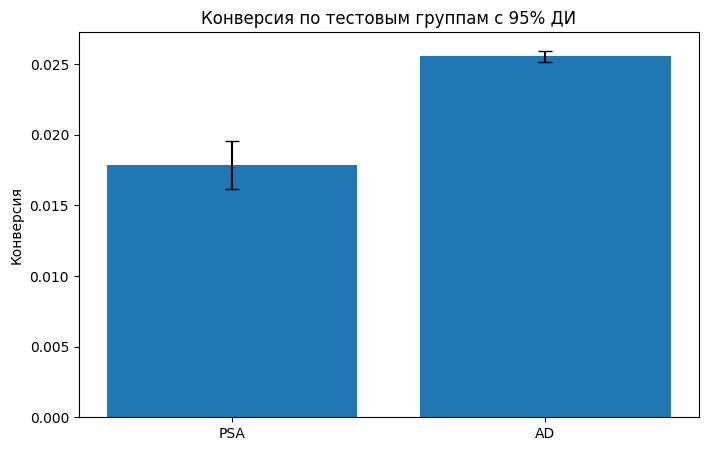

In [136]:
def calc_ci(successes, n, confidence=0.95):
    z = 1.96
    p = successes / n
    se = np.sqrt(p * (1 - p) / n)
    return p - z * se, p + z * se

ci_psa = calc_ci(df[df['test_group'] == 'psa']['converted'].sum(), n_psa)
ci_ad = calc_ci(df[df['test_group'] == 'ad']['converted'].sum(), n_ad)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['PSA', 'AD'], [conv_psa, conv_ad])
ax.errorbar(['PSA', 'AD'], [conv_psa, conv_ad],
            yerr=[[conv_psa - ci_psa[0], conv_ad - ci_ad[0]],
                  [ci_psa[1] - conv_psa, ci_ad[1] - conv_ad]],
            fmt='none', color='black', capsize=5)
ax.set_ylabel('Конверсия')
ax.set_title('Конверсия по тестовым группам с 95% ДИ')
plt.show()

Видим, что конверсия группы ad выше конверсии в группе psa (разница примерно в 43%). По графику с построенными доверительными интервалами видим, что ширина ДИ для группы ad меньше (то есть полученная оценка более точная), что связано с гораздо большей долей значений в выборке.

##### Сравнение total_ads по тестовым группам

In [143]:
total_ads_ad = df[df['test_group'] == 'ad']['total_ads'].mean()
total_ads_psa = df[df['test_group'] == 'psa']['total_ads'].mean()

In [207]:
print('Количество показов рекламы в группе ad:', total_ads_ad)
print('Количество показов рекламы в группе psa:', total_ads_psa)
print('Разница количества показов рекламы:', total_ads_ad - total_ads_psa)
print('Относительный прирост:', (total_ads_ad - total_ads_psa) / total_ads_psa)

Количество показов рекламы в группе ad: 24.823365103431417
Количество показов рекламы в группе psa: 24.761137561639178
Разница количества показов рекламы: 0.06222754179223955
Относительный прирост: 0.0025131132056163945


По расчёту видим, что разницы в общем количестве показов рекламы для разных тестовых групп не наблюдается.

##### Сравнение конверсии в тестовых группах по дням недели

In [174]:
conv_by_day_group = df.groupby(['test_group', 'most_ads_day'])['converted'].agg(lambda x: x.sum() / x.count() * 100).reset_index()
conv_by_day_group.columns = ['test_group', 'most_ads_day', 'share']
conv_by_day_group

,test_group,most_ads_day,share
0,ad,Friday,2.246495
1,ad,Monday,3.324120
2,ad,Saturday,2.130657
3,ad,Sunday,2.461983
4,ad,Thursday,2.163714
5,ad,Tuesday,3.044038
6,ad,Wednesday,2.535586
7,psa,Friday,1.630292
8,psa,Monday,2.255854
9,psa,Saturday,1.399580


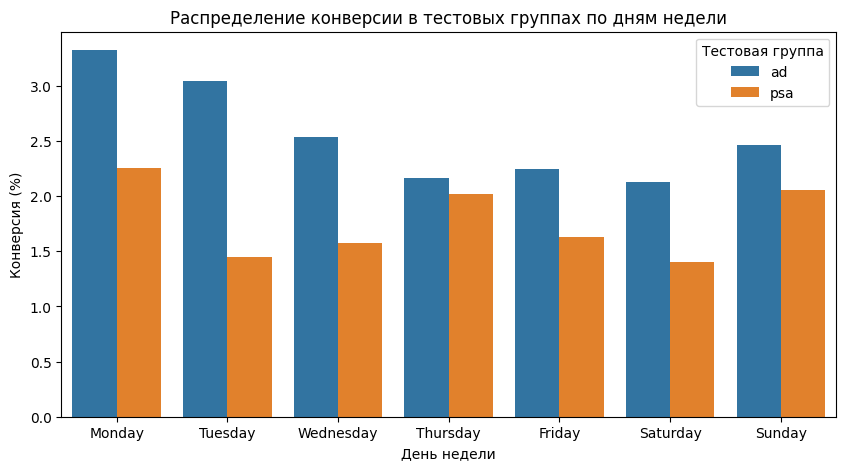

In [175]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 5))
sns.barplot(data=conv_by_day_group, x='most_ads_day', y='share', hue='test_group', order=day_order)
plt.legend(title='Тестовая группа')
plt.title('Распределение конверсии в тестовых группах по дням недели')
plt.xlabel('День недели')
plt.ylabel('Конверсия (%)')
plt.show()

По графику видим, что в среднем конверсия группы ad выше конверсии группы psa. Наибольшая конверсия для обеих групп достигается в понедельник, наименьшая - в субботу. При этом для конверсии в группе ad характерна периодичность - пик достигается в понедельник, после идет проседание с самыми низкими значениями с четверга по субботу и далее следует подъём в воскресенье. Для конверсии в группе psa характерны несколько падений и взлётов в течение недели.

##### Сравнение конверсий в тестовых группах по часам

In [179]:
conv_by_hour_group = df.groupby(['test_group', 'most_ads_hour'])['converted'].agg(
    lambda x: x.sum() / x.count() * 100).reset_index()
conv_by_hour_group.columns = ['test_group', 'most_ads_hour', 'conv_share']
conv_by_hour_group

,test_group,most_ads_hour,conv_share
0,ad,0,1.921266
1,ad,1,1.343445
2,ad,2,0.756988
3,ad,3,1.042471
4,ad,4,1.585014
5,ad,5,2.156334
6,ad,6,2.317380
7,ad,7,1.848249
8,ad,8,1.986091
9,ad,9,1.952889


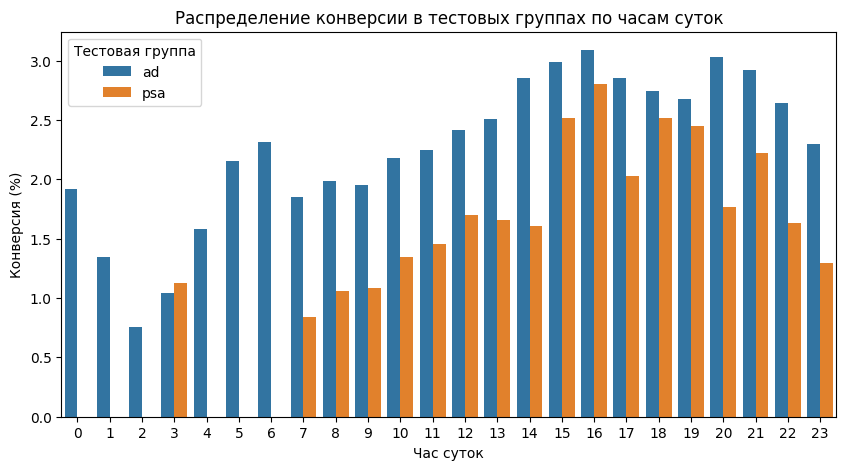

In [182]:
plt.figure(figsize=(10, 5))
sns.barplot(data=conv_by_hour_group, x='most_ads_hour', y='conv_share', hue='test_group')
plt.title('Распределение конверсии в тестовых группах по часам суток')
plt.xlabel('Час суток')
plt.ylabel('Конверсия (%)')
plt.legend(title='Тестовая группа')
plt.show()

По графику видим, что в среднем конверсия в группе ad выше конверсии в группе psa, но в 3 часа ночи конверсия psa превышает конверсию ad (примерно на 8%). Также заметим, что конверсия в группе psa обеспечивается не во все часы суток (имеет нулевой показатели в 6 из 24 часов, то есть четверть суток). Наибольшее значение обе конверсии достигают в 16 часов, наименьшее значение для конверсии ad - в 2 часа, для конверсии psa - в 0, 1, 2, 4, 5, 6 часов (нулевая). Конверсии показывают зависимость от режима дня пользователей - возрастают в часы пробуждения, возвращения с работы/учёбы и в свободное вечернее время и уменьшаются в рабочее/учебное время и время сна.

##### Сравнение конверсий тестовых групп в зависимости от числа показов

In [192]:
df['ads_bin'] = pd.cut(df['total_ads'],
                       bins=[0, 1, 2, 5, 10, 20, 50, 100, float('inf')],
                       labels=['0', '1', '2-5', '6-10', '11-20', '21-50', '51-100', '100+'])
df['ads_bin']

,ads_bin
0,100+
1,51-100
2,21-50
3,100+
4,100+
...,...
588096,0
588097,0
588098,2-5
588099,0


In [199]:
conv_by_ads_group = df.groupby(['test_group', 'ads_bin'])['converted'].agg(
    lambda x: x.sum() / x.count() * 100).reset_index()
conv_by_ads_group.columns = ['test_group', 'ads_bin', 'conv_share']
conv_by_ads_group

/tmp/ipykernel_3915/2527862307.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conv_by_ads_group = df.groupby(['test_group', 'ads_bin'])['converted'].agg(


,test_group,ads_bin,conv_share
0,ad,0,0.158385
1,ad,1,0.240036
2,ad,2-5,0.321531
3,ad,6-10,0.485309
4,ad,11-20,0.839995
5,ad,21-50,2.915382
6,ad,51-100,11.631068
7,ad,100+,17.135214
8,psa,0,0.129983
9,psa,1,0.156576


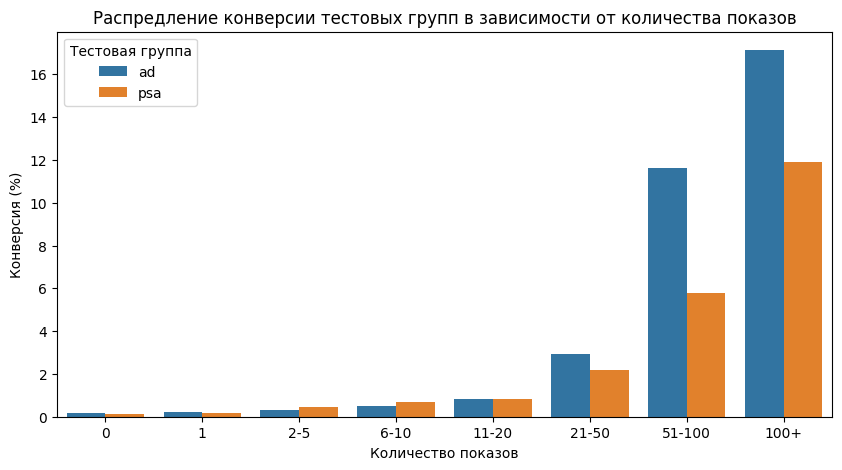

In [201]:
plt.figure(figsize=(10, 5))
sns.barplot(data=conv_by_ads_group, x='ads_bin', y='conv_share', hue='test_group')
plt.legend(title='Тестовая группа')
plt.title('Распредление конверсии тестовых групп в зависимости от количества показов')
plt.xlabel('Количество показов')
plt.ylabel('Конверсия (%)')
plt.show()

По графику видим, что конверсия обеих групп растет при увеличении числа показов. Конверсия psa выше конверсии ad при значениях показа от 2 до 10, в значении от 11 до 20 показов показатели конверсий примерно одинаковы, при значениях меньше 2 и больших 20 конверсия ad выше.

### Статистические проверки гипотез

Проверим следующие гипотезы:
* Значения конверсий в тестовых группах равны
* Значения количества показов для тестовых групп совпадают

##### Проверим гипотезу о равенстве конверсий. Н0: Конверсии тестовых групп совпадают. Н1: Конверсии тестовых групп различаются. Для проверки будем использовать Z-тест, так как конверсия - бинарная переменная, в усреднении дающая пропорцию.

In [204]:
from statsmodels.stats.proportion import proportions_ztest

successes = [df[df['test_group'] == 'ad']['converted'].sum(),
             df[df['test_group'] == 'psa']['converted'].sum()]
nobs = [n_ad, n_psa]

alpha = 0.05
zstat, pvalue = proportions_ztest(successes, nobs, alternative='two-sided')
print('p-value:', pvalue)

if pvalue < alpha:
  print('Отвергаем нулевую гипотезу')
else:
  print('Не отвергаем нулевую гипотезу')

p-value: 1.7052807161559727e-13
Отвергаем нулевую гипотезу


In [217]:
import math

p_psa = successes[0] / nobs[0]
p_ad = successes[1] / nobs[1]
h_effect = abs(2 * math.asin(math.sqrt(p_ad)) - 2 * math.asin(math.sqrt(p_psa)))

print("Cohen's h:", h_effect)

Cohen's h: 0.053002578606030915


По результату Z-теста конверсии тестовых групп имеют статистически значимое различие. После расчета размера эффекта можно придти к выводу, что разница конверсий практически незначима. Таким образом, для окончательной оценки необходимо провести дополнительный анализ, учитывающий экономические показатели групп.

##### Проверим гипотезу о равенстве количества показов в тестовых группах. Н0: Количества показов тестовых групп совпадают. Н1: Количества показов тестовых групп различаются. Для проверки будем использовать критерий Манна-Уитни, так как total_ads сильно скошенно.

In [236]:
from scipy.stats import mannwhitneyu

stat, pvalue = mannwhitneyu(
    df[df['test_group'] == 'ad']['total_ads'],
    df[df['test_group'] == 'psa']['total_ads'], alternative='two-sided')
print('p-value:', pvalue)
delta = abs((2 * stat) / (n_ad * n_psa) - 1)
print('delta:', delta)

if pvalue < alpha:
  print('Отвергаем нулевую гипотезу')
else:
  print('Не отвергаем нулевую гипотезу')

p-value: 4.6909108547205694e-11
delta: 0.02525896649217163
Отвергаем нулевую гипотезу


По результатам теста видим, что разница между числом показов тестовых групп является статистически значимой (с относительным приростом 0.25%), однако практическая значимость различия числа показов является пренебрежимо малой (размер эффекта: cliff's delta = 0.025 < 0.147). Таким образом, несмотря на статистическую значимость разница числа показов между тестовыми группами является практически незначимой.

### Анализ аномалий и очистка данных

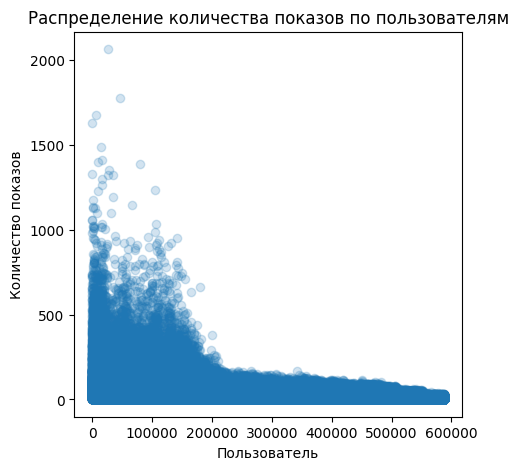

In [228]:
plt.figure(figsize=(5, 5))
plt.scatter([x for x in range(len(df))], df['total_ads'], alpha=0.2)
plt.title('Распределение количества показов по пользователям')
plt.xlabel('Пользователь')
plt.ylabel('Количество показов')
plt.show()

Число пользователей с количеством показов больше 500 мало. Есть выбросы в районе 500-2200 показов.

Рассчитаем 95-й и 99-й перцентили количества показов

In [229]:
print(np.percentile(df['total_ads'], [95, 99]))

[ 88. 202.]


Для 5% пользователей число показов больше 88. Для 1% пользователей - больше 202.

Примем за аномалию количество показов больше 150. Удалим аномальные данные.

In [230]:
clean_df = df[df['total_ads'] <= 150]
clean_df.head()

,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour,ads_bin
0,1069124,ad,0,130,Monday,20,100+
1,1119715,ad,0,93,Tuesday,22,51-100
2,1144181,ad,0,21,Tuesday,18,21-50
7,1496843,ad,0,17,Sunday,18,11-20
8,1448851,ad,0,21,Tuesday,19,21-50


### Повторные статистические проверки после очистки данных

In [231]:
successes = [clean_df[clean_df['test_group'] == 'ad']['converted'].sum(),
             clean_df[clean_df['test_group'] == 'psa']['converted'].sum()]
nobs = [len(clean_df[clean_df['test_group'] == 'ad']),
        len(clean_df[clean_df['test_group'] == 'psa'])]

alpha = 0.05
zstat, pvalue = proportions_ztest(successes, nobs, alternative='two-sided')
print('p-value:', pvalue)

if pvalue < alpha:
  print('Отвергаем нулевую гипотезу')
else:
  print('Не отвергаем нулевую гипотезу')

p-value: 5.2737178962742296e-14
Отвергаем нулевую гипотезу


In [259]:
import math

p_psa = successes[0] / nobs[0]
p_ad = successes[1] / nobs[1]
h_effect = abs(2 * math.asin(math.sqrt(p_ad)) - 2 * math.asin(math.sqrt(p_psa)))

print('Cohen\'s h:', h_effect)

Cohen's h: 0.05512086377568226


Результаты совпадают с результатами по неочищенным данным. Показатели p-value и размера эффекта стали ниже.

In [235]:
stat, pvalue = mannwhitneyu(
    clean_df[clean_df['test_group'] == 'ad']['total_ads'],
    clean_df[clean_df['test_group'] == 'psa']['total_ads'], alternative='two-sided')
print('p-value:', pvalue)
delta = abs((2 * stat) / (n_ad * n_psa) - 1)
print('delta:', delta)

if pvalue < alpha:
  print('Отвергаем нулевую гипотезу')
else:
  print('Не отвергаем нулевую гипотезу')

p-value: 1.8371844203238143e-13
delta: 0.010521302350472883
Отвергаем нулевую гипотезу


Результаты совпадают с результатами, полученными на неочищенных данных. Показатели p-value и размера эффекта стали меньше.

### Расчёт ROI

Предположим, что средняя выручка с конверсии составляет 1000 руб., затраты на показ рекламного объявления 20 руб. Рассчитаем ROI для таких показателей.

In [272]:
n_ad = len(clean_df[clean_df['test_group'] == 'ad'])
n_psa = len(clean_df[clean_df['test_group'] == 'psa'])
conv_ad = clean_df[clean_df['test_group'] == 'ad']['converted'].mean()
conv_psa = clean_df[clean_df['test_group'] == 'psa']['converted'].mean()

avg_order_value = 1000
cost_per_ad = 20

incremental_conversions = n_ad * conv_ad - n_psa * conv_psa

revenue_ad = n_ad * conv_ad * avg_order_value
revenue_psa = n_psa * conv_psa * avg_order_value
incremental_revenue = revenue_ad - revenue_psa

cost_ad = n_ad * cost_per_ad
cost_psa = n_psa * cost_per_ad
incremental_cost = cost_ad - cost_psa

roi = (incremental_revenue - incremental_cost) / incremental_cost * 100

print('Дополнительная выручка:', incremental_revenue)
print('Дополнительные затраты:', incremental_cost)
print('ROI (%):', roi)

Дополнительная выручка: 12410000.0
Дополнительные затраты: 10626600
ROI (%): 16.78241394237103


ROI > 0 и составляет примерно 17%, следовательно, внедрение ad прибыльно.

Рассчитаем точку безубыточности при фиксированном значении затрат на рекламу в 20 руб.

In [274]:
break_even_value = incremental_cost / incremental_conversions
print('Точка безубыточности:', break_even_value)

Точка безубыточности: 856.2933118452861


Исходя из расчета, для окупаемости ремламы необходимо, чтобы прибыль с каждой конверсии состовляла не менее 857 руб.

### Общие выводы

* Есть статистически значимое, но малое практически значимое различие между конверсиями тестовых групп как до, так и после удаления аномальных значений
* Нет статистически значимой разницы между количеством показов тестовых групп
* Согласно графику сравнения конверсий группа В (ad) показывает более высокую конверсию, чем группа А (psa). Наблюдается относительный прирост в среднем на 43% относительно группы А
* В среднем конверсия достигает самых высоких показателей для обеих групп в понедельник

Таким образом, тест можно остановить. Если целью развития является увеличение конверсии, то тест можно признать успешным и зафиксировать победу группы В. Если целью развития является увеличение прибыли, то необходимо провести дополнительный экономический анализ. На данный момент была проведена оценка ROI на основе гипотетических данных, по результатам которой зафиксирована победа группы В.